
--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        14

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



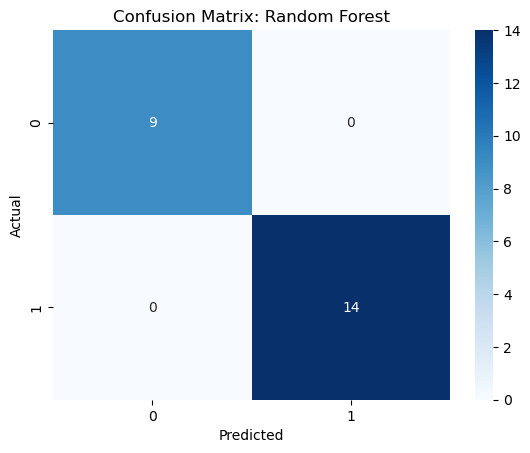


--- Naive Bayes ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        14

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



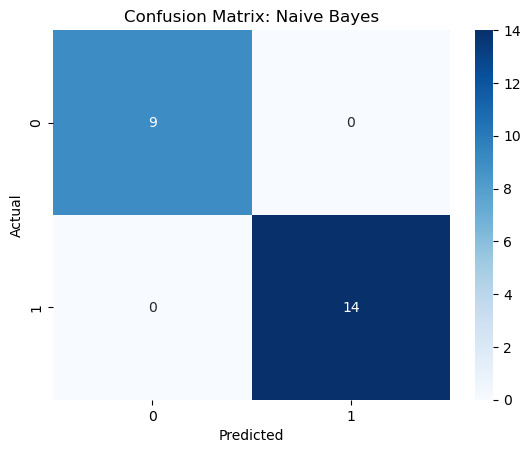


--- SVM (RBF Kernel) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        14

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



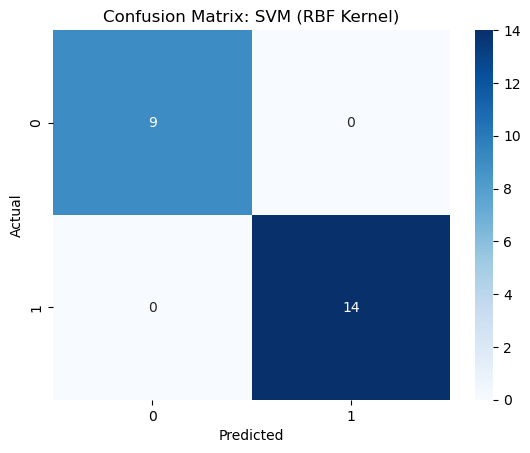

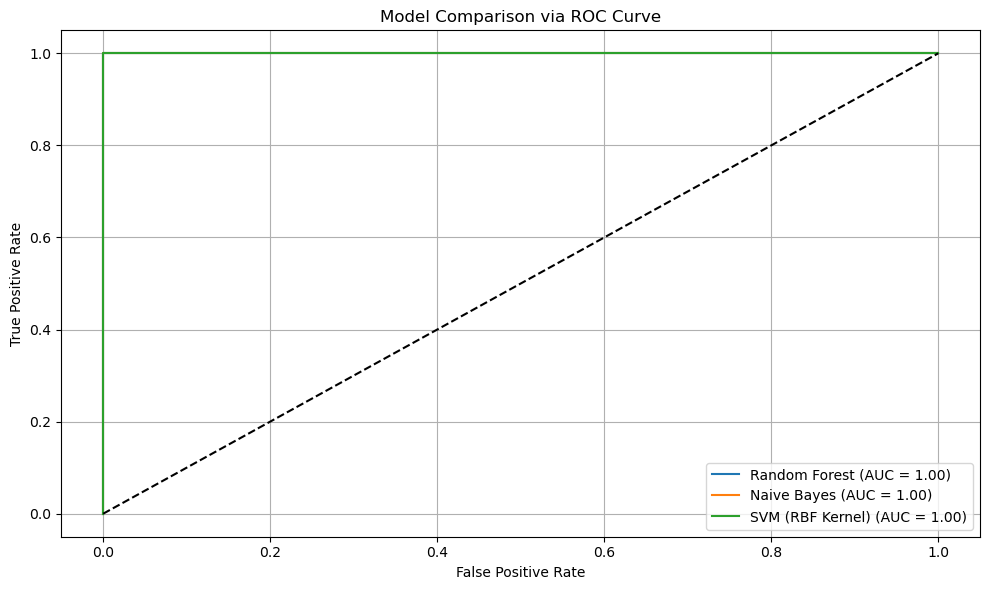

In [5]:
#here i imported necessary modules for data processing and ML modeling
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

#here i am Loading the raw dataset
dataset = pd.read_csv("cwdata.csv")

#here i  Droping unnecessary rows and columns if they exist
dataset = dataset.drop(index=range(120, 122), errors='ignore')
dataset = dataset.drop(columns=["Unnamed: 10"], errors='ignore')

#here i am Renaming columns to avoid spaces
dataset.columns = dataset.columns.str.replace(" ", "_").str.strip()

#here i am gona Standardize binary columns
binary_map = {'yes': 1, 'no': 0, 'y': 1, 'n': 0, '1': 1, '0': 0}
for field in ['Employed', 'Home_Owner', 'Fraud']:
    dataset[field] = dataset[field].astype(str).str.lower().map(binary_map)

#i will Normalize gender values here
def simplify_gender(x):
    x = str(x).lower()
    if 'f' in x:
        return 'Female'
    elif 'm' in x:
        return 'Male'
    else:
        return 'Unknown'
dataset['Gender'] = dataset['Gender'].apply(simplify_gender)

# here i will Collapse education into categories
def group_education(x):
    x = str(x).lower()
    if 'univ' in x or x == 'u':
        return 'Uni'
    elif 'college' in x:
        return 'College'
    elif 'school' in x:
        return 'School'
    else:
        return 'Other'
dataset['Education'] = dataset['Education'].apply(group_education)

#here i will Convert area info to Urban/Rural
def format_area(val):
    val = str(val).lower()
    return 'Urban' if val.startswith('u') else 'Rural' if val.startswith('r') else 'Unknown'
dataset['Area'] = dataset['Area'].apply(format_area)

#now i will do Numeric conversion and cleaning
for col in ['Income', 'Balance', 'Age']:
    dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

dataset = dataset.dropna()

#now i am gona Convert to correct types
dataset['Employed'] = dataset['Employed'].astype(int)
dataset['Home_Owner'] = dataset['Home_Owner'].astype(int)
dataset['Fraud'] = dataset['Fraud'].astype(int)
dataset['Age'] = dataset['Age'].astype(int)

#here i am gona label encode categorical features
label_cols = ['Gender', 'Education', 'Area', 'Colour']
for col in label_cols:
    le = LabelEncoder()
    dataset[col] = le.fit_transform(dataset[col].astype(str))

#this will Save intermediate data
dataset.to_csv("cleaned_dataset.csv", index=False)

#i will Separate features and labels here
features = dataset.drop(columns=['Fraud'])
labels = dataset['Fraud']

#and now Training and test split (80/20)
train_X, test_X, train_y, test_y = train_test_split(features, labels, test_size=0.2, random_state=101)

#here Normalize using MinMaxScaler
scaler = MinMaxScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

#now Classifiers to compare
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=101),
    "Naive Bayes": GaussianNB(),
    "SVM (RBF Kernel)": SVC(probability=True, kernel='rbf', random_state=101)
}

#this will Evaluate and store ROC info
roc_info = {}

for model_name, clf in classifiers.items():
    clf.fit(train_X_scaled, train_y)
    preds = clf.predict(test_X_scaled)
    probs = clf.predict_proba(test_X_scaled)[:, 1]

    print(f"\n--- {model_name} ---")
    print(classification_report(test_y, preds))

    cm = confusion_matrix(test_y, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(test_y, probs)
    auc_val = roc_auc_score(test_y, probs)
    roc_info[model_name] = (fpr, tpr, auc_val)

#here we are plotting combined roc curves
plt.figure(figsize=(10, 6))
for model_name, (fpr, tpr, auc_val) in roc_info.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_val:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Model Comparison via ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
